In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets, fixed
from dtw import dtw
from scipy import interpolate


In [2]:
def get_data(df, row_name):
    data = []

    for i, row in df.iterrows():
        if not pd.isna(row[row_name]):
            data.append([i,row[row_name]])

    return np.asarray(data)    

In [34]:
def parse_data(df, row_name,header_length = 1):
    data = []

    for i, row in df.iterrows():
        if i+1 > header_length:
            data.append([i,row[row_name]])

    return np.asarray(data)    

In [3]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [4]:
def anchored_dtw(x, y, anchors, **dtw_kwargs):
    anchors = sorted(anchors)

    full_index1 = []
    full_index2 = []
    total_distance = 0.0

    for (i_start, j_start), (i_end, j_end) in zip(anchors[:-1], anchors[1:]):
        x_seg = x[i_start:i_end + 1]
        y_seg = y[j_start:j_end + 1]

        alignment = dtw(
            x_seg,
            y_seg,
            keep_internals=True,
            **dtw_kwargs
        )

        idx1 = np.array(alignment.index1) + i_start
        idx2 = np.array(alignment.index2) + j_start

        if len(full_index1) > 0:
            idx1 = idx1[1:]
            idx2 = idx2[1:]

        full_index1.extend(idx1)
        full_index2.extend(idx2)
        total_distance += alignment.distance

    return np.array(full_index1), np.array(full_index2), total_distance

In [41]:
def dynamic_draw(values, x_pos):

    values = np.asarray(values, dtype=float)

    point_y = values[x_pos]

    fig, ax = plt.subplots()
    ax.plot(values)

    if not np.isnan(point_y):
        ax.scatter(x_pos, point_y, label=f'{x_pos}')
        ax.legend(loc='upper right')
    else:
        ax.legend('No valid data',loc='upper right')
        
    plt.show()

In [6]:
xl_file = pd.ExcelFile('I_full data.xlsx')

dfs = {sheet_name: xl_file.parse(sheet_name) 
          for sheet_name in xl_file.sheet_names}

In [7]:
dfs['B'].columns

Index(['thickness, mm', 'Piece', 'sample №', 'thick, mm', 'weight, g',
       'Vol, cm3', 'depth, mm', 'Dgeo', 'Igeo', 'MADgeo', 'NRMmax (Am2/kg)',
       'ARMmax (Am2/kg)'],
      dtype='str')

In [8]:
sheet_B = dfs['C']

In [9]:
sheet_C = dfs['B']

In [35]:
sample_1 = parse_data(sheet_B, 'Igeo', 1)
sample_2 = parse_data(sheet_C, 'Igeo', 1)

In [42]:
interact(
    dynamic_draw,
    #idx = fixed(sample_1[:,0]),
    values = fixed(sample_1[:,1]),
    x_pos = widgets.IntSlider(min = 0, max = sample_1[:,0].shape[0] - 1)
)

interactive(children=(IntSlider(value=0, description='x_pos', max=35), Output()), _dom_classes=('widget-intera…

<function __main__.dynamic_draw(values, x_pos)>

In [43]:
interact(
    dynamic_draw,
    #idx = fixed(sample_2[:,0]),
    values = fixed(sample_2[:,1]),
    x_pos = widgets.IntSlider(min = 0, max = sample_2[:,0].shape[0] - 1)
)

interactive(children=(IntSlider(value=0, description='x_pos', max=36), Output()), _dom_classes=('widget-intera…

<function __main__.dynamic_draw(values, x_pos)>

In [13]:
anchors = [
    (0, 0),
    (4, 4),
    (15, 14),
    (28, 28),
    (len(sample_1[:, 1]) - 1, len(sample_2[:, 1]) - 1)
]

In [61]:
sample_2_interp = (
    pd.Series(sample_2[:, 1])
    .interpolate(limit_direction="both")
    .to_numpy()
)

sample_1_interp = (
    pd.Series(sample_1[:, 1])
    .interpolate(limit_direction="both")
    .to_numpy()
)

In [62]:
idx1, idx2, dist = anchored_dtw(
    sample_1_interp,
    sample_2_interp,
    anchors,
    step_pattern="symmetric2"
)

In [63]:
aligned_1_values = sample_1[idx1, 1]
aligned_2_values = sample_2[idx2, 1]

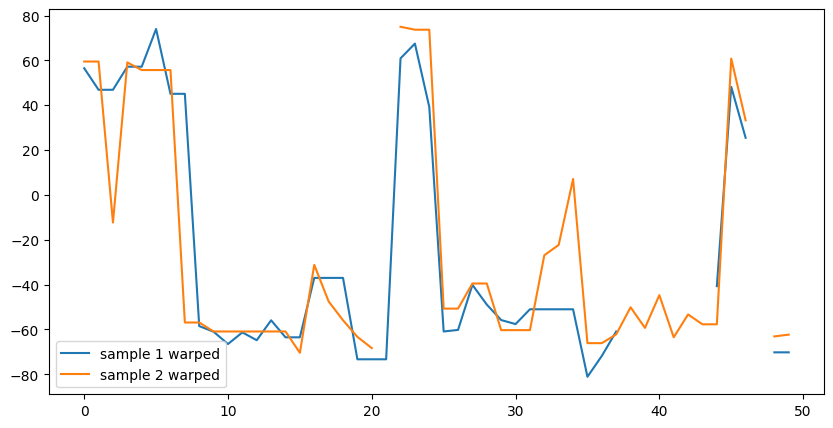

In [64]:
plt.figure(figsize=(10, 5))

plt.plot(sample_1[idx1, 1], label="sample 1 warped")
plt.plot(sample_2[idx2, 1], label="sample 2 warped")

plt.legend()
plt.show()

In [67]:
D_1 = parse_data(sheet_B, 'ARMmax (Am2/kg)')
D_2 = parse_data(sheet_C, 'ARMmax (Am2/kg)')

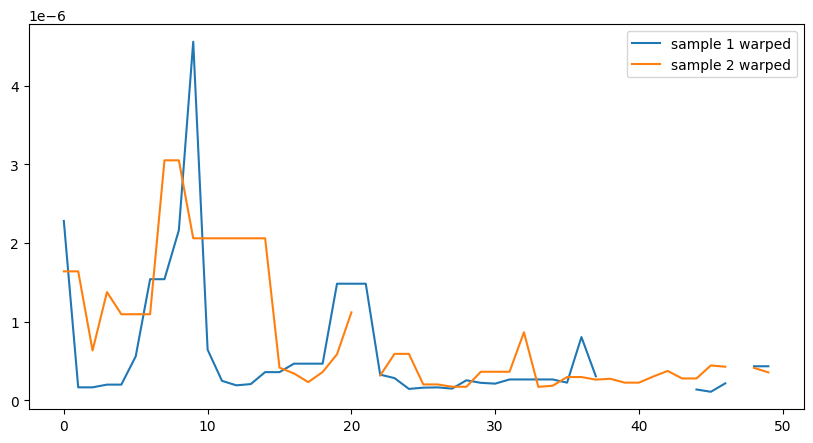

In [68]:
plt.figure(figsize=(10, 5))

plt.plot(D_1[idx1, 1], label="sample 1 warped")
plt.plot(D_2[idx2, 1], label="sample 2 warped")

plt.legend()
plt.show()